# per importare i file d google drive

In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab.patches import cv2_imshow
import os
import sys
import gzip
import math



import cv2
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix
from sklearn.cluster import DBSCAN

from __future__ import print_function
import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from keras import backend as K
from sklearn.model_selection import train_test_split


#  MODELLO - Inizio
from scipy.io import loadmat

file_path = '/content/drive/MyDrive/emnist-byclass.mat'
data = loadmat(file_path)

print(data.keys())  # Controlla le chiavi presenti nel file

train_images = data["dataset"][0][0][0][0][0][0]  # Immagini di training
train_labels = data["dataset"][0][0][0][0][0][1]  # Etichette di training

# Normalizzazione
train_images = train_images.reshape(-1, 28, 28).astype("float32") / 255.0

# Correzione dell'orientamento
def orientamento_immagini(images):
    return np.array([np.flip(np.rot90(img, -1), axis=1) for img in images])

train_images_fixed = orientamento_immagini(train_images)
indici = [12, 13, 15, 28, 31, 33]  # C, D, F, S, V, X
lookup = {'12': 0, '13': 1, '15': 2, '28': 3, '31': 4, '33': 5}

indici_contigui = [i for i, label in enumerate(train_labels) if label in indici]
indici_images_i = [train_images_fixed[i] for i in indici_contigui]
indici_labels_i = [lookup[str(train_labels[i][0])] for i in indici_contigui]

# Converti in array numpy
indici_images_i = np.array(indici_images_i).astype("float32")
indici_labels_i = np.array(indici_labels_i)

x_train, x_test, y_train, y_test = train_test_split(indici_images_i, indici_labels_i, test_size=0.2, random_state=42)




dict_keys(['__header__', '__version__', '__globals__', 'dataset'])


In [3]:
def create_model(num_classes): #creazione modello
  input_layer = layers.Input(shape=(784,), name="input_layer")
  reshaped = layers.Reshape((28, 28, 1), input_shape=(784,))(input_layer)

  cnn_layer = layers.Conv2D(32, (3, 3), activation="relu", name="conv_layer_1")(reshaped)
  cnn_layer = layers.MaxPooling2D(pool_size=(2, 2), name="maxpool_layer_1")(cnn_layer)
  cnn_layer = layers.Conv2D(32, (5, 5), activation="relu", name="conv_layer_2")(cnn_layer)
  cnn_layer = layers.MaxPooling2D(pool_size=(2, 2), name="maxpool_layer_2")(cnn_layer)

  inner_layer = layers.Dropout(rate=0.2, name="drop_layer")(cnn_layer)
  inner_layer = layers.Flatten(name="flatten_layer")(inner_layer)

  dense_layer = layers.Dense(128, activation="relu", name="dense_layer_1")(inner_layer)
  dense_layer = layers.Dropout(rate=0.2, name="drop_layer2")(dense_layer)
  dense_layer = layers.Dense(64, activation="relu", name="dense_layer_2")(dense_layer)

  output_layer = layers.Dense(num_classes, activation="softmax", name="output_layer")(dense_layer)

  model = Model(inputs=[input_layer], outputs=[output_layer])
  model.summary()
  model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
  return model





In [4]:
def creaModello():

  num_classes = 6  # Cambiato da 26 a 6 per le classi C, D, F, S, V, X


  #  Utilizzo dei dati già processati dal nuovo modello

  # Reshape a 784 features (28x28)
  feature_vector_length = 784
  x_train_flat = x_train.reshape(x_train.shape[0], feature_vector_length)
  x_test_flat = x_test.reshape(x_test.shape[0], feature_vector_length)

  model = create_model(num_classes)
  batch_size = 128
  epochs = 16

  history = model.fit(x_train_flat, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test_flat, y_test))
  score = model.evaluate(x_test_flat, y_test, verbose=0)
  print("Test loss:", score[0])
  print("Test accuracy:", score[1])
  model.save('modello.h5')
  return model, history

def previsioni(n, m, quadrati, model):
    # Lista per memorizzare le lettere previste
    lettere_previste = []

    for indice in range(1, quadrati + 1):
        img = cv2.imread(f'cella_{indice}.png', cv2.IMREAD_GRAYSCALE)
        img = cv2.bitwise_not(img)
        img = cv2.resize(img, (28, 28))
        img = img.astype('float32') / 255
        img = img.reshape(1, 28 * 28)
        img = 1 - img
        predictions = np.argmax(model.predict(img), axis=-1)
        label = predictions[0]

        # Mapping delle classi
        classi = ['c', 'd', 'f', 's', 'v', 'x']
        etichetta = classi[label]

        # Aggiungi la lettera predetta alla lista
        lettere_previste.append(etichetta)

    return lettere_previste


In [5]:
#pulizia dell'imagine

from itertools import product

def coppie_adiacenti(seq):
    it = iter(seq)
    first_val = next(it)
    val1 = first_val
    for val2 in it:
        yield val1, val2
        val1 = val2
    yield val1, first_val

def rect_area(rect):
    x, y, w, h = rect
    return h*w

def disegna_linee(image, line, color, thickness=1):
    h, w, *_ = image.shape
    rho, theta = line
    a = math.cos(theta)
    b = math.sin(theta)

    if np.pi/4 <= theta < np.pi*3/4:
        p1 = 0, round(rho/b)
        p2 = w, round((rho - w*a)/b)
    else:
        p1 = round(rho/a), 0
        p2 = round((rho - h*b)/a), h

    return cv2.line(image, p1, p2, color, thickness)

def media_linee(lines):
    lines = np.array(lines)
    for i, (rho, theta) in enumerate(lines):
        if theta > np.pi*3/4:
            lines[i] = -rho, theta-np.pi

    rhos, thetas = lines.T
    scale = abs(min(rhos)-max(rhos))/np.pi
    scaled_lines = np.column_stack((rhos, thetas*scale))
    model = DBSCAN(eps=24, min_samples=1)
    model.fit(scaled_lines)
    clusters = {}
    for label, line in zip(model.labels_, lines):
        clusters.setdefault(label, []).append(line)
    mean_lines = []
    for label, line_cluster in clusters.items():
        # Use np.mean instead of the undefined 'mean'
        mean_lines.append(np.apply_along_axis(np.mean, 0, np.array(line_cluster)))
    for i, (rho, theta) in enumerate(mean_lines):
        if theta < 0:
            mean_lines[i] = -rho, theta+np.pi
    return mean_lines
def intersezioni_linee(l1, l2):
    rho1, theta1 = l1
    rho2, theta2 = l2
    ct1 = math.cos(theta1)
    st1 = math.sin(theta1)
    ct2 = math.cos(theta2)
    st2 = math.sin(theta2)
    det = ct1*st2 - st1*ct2
    if det:
        return (int((st2*rho1 - st1*rho2)/det),
                int((-ct2*rho1 + ct1*rho2)/det))
    else:
        raise ValueError("l1 and l2 are parallel")

def distanza_punti(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    return math.sqrt((x1-x2)**2 + (y1-y2)**2)

def distanza_bordo(image, point):
    x, y = point
    h, w, *_ = image.shape
    return min(x, w-x-1, y, h-y-1)

def blob_griglia(image):
    h, w = image.shape
    search_image = cv2.bitwise_and(image, 64)
    best_area = 0
    largest_blob = None
    for y, x in product(range(h), range(w)):
        if not search_image[y, x]:
            continue
        area, filled, _, _ = cv2.floodFill(search_image, None, (x, y), 255)
        if area > best_area:
            best_area = area
            largest_blob = np.copy(filled)
        _, search_image, _, _ = cv2.floodFill(search_image, None, (x, y), 0)
    _, largest_blob = cv2.threshold(largest_blob, 127, 255, cv2.THRESH_BINARY)
    return largest_blob

def punteggio_blob(image, blob_color=255):
    h, w, *_ = image.shape
    return sum(
            distanza_bordo(image, (x, y))
            for y, x in product(range(h), range(w))
            if image[y, x] == blob_color)

def blob_cella(image):
    h, w, *_ = image.shape
    min_area = (min(h, w)//10)**2
    image = cv2.bitwise_and(image, 64)
    best_blob = None
    best_score = 0
    for y, x in product(range(h), range(w)):
        if not image[y, x]:
            continue
        area, _, _, _ = cv2.floodFill(image, None, (x, y), 255)
        if area > min_area:
            blob_score = punteggio_blob(image, blob_color=255)
            if blob_score > best_score:
                best_score = blob_score
                _, best_blob = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
        cv2.floodFill(image, None, (x, y), 0)
    return best_blob

def ritaglia_contenuto(image):
    h, w, *_ = image.shape
    x, y = w, h
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    x, y, w, h = cv2.boundingRect(np.concatenate(contours))
    return image[y:y+h, x:x+w]

def ritaglia_cella(image, relative_size):
    h, w, *_ = image.shape
    side = int(max(h, w) * relative_size)
    x = (side-w) // 2
    y = (side-h) // 2
    ret_image = np.zeros((side, side), dtype=image.dtype)
    ret_image[y:y+h, x:x+w] = image
    return ret_image

def pulisci_cella(image):
    for i in range(4):
        image = cv2.medianBlur(image, 3)
    image = cv2.pyrUp(image)
    image = cv2.blur(image, (3, 3))
    return image

def alpha_beta_correction(image, alpha, beta):
    image = image.astype(np.float32)
    return np.clip(image*alpha + beta, 0, 255).astype(np.uint8)

def gamma_correction(image, gamma):
    lookup_table = np.arange(256).reshape((1, 256))
    lookup_table = np.clip((lookup_table/255)**gamma * 255, 0, 255)
    lookup_table = lookup_table.astype(np.uint8)
    return cv2.LUT(image, lookup_table)

def chiudi(n, m):
  print("matrice non quadrata")
  sys.exit()

def creaStatoGol(n, m, s):
  rows = int(n)
  cols = int(m)
  stanzaPulita = []
  conta = 0
  room, x, y = s
  for i in range(rows):
    row = []
    for j in range(cols):
      if(room[i][j] != "s" and room[i][j] != "f"
         and room[i][j] != "c" and room[i][j] != "x"):
        row.append("c")
      else:
        row.append(room[i][j])
    stanzaPulita.append(row)
  contas=0
  contaf=0
  pos_fi = 0
  pos_fj = 0
  for i in range(rows):
    for j in range(cols):
      if(stanzaPulita[i][j] == "s"):
        contas+=1
      if(stanzaPulita[i][j] == "f"):
        contaf+=1
        pos_fi = i
        pos_fj = j
  if(contas!=1 or contaf!=1):
    print("Errore: Nell'immagine è presente più di uno stato iniziale/finale")
  else:
    stanzaPulita = stanzaPulita,pos_fi, pos_fj
    return stanzaPulita

In [6]:
def creaStanza(n, m, c):
  rows = int(n)
  cols = int(m)
  stanza = []
  conta = 0
  for i in range(rows):
    row = []
    for j in range(cols):
      row.append(c[conta])
      conta+=1
    stanza.append(row)
  contas=0
  contaf=0
  pos_si = 0
  pos_sj = 0
  for i in range(rows):
    for j in range(cols):
      if(stanza[i][j] == "s"):
        contas+=1
        pos_si = i
        pos_sj = j
      if(stanza[i][j] == "f"):
        contaf+=1
  if(contas!=1 or contaf!=1):
    print("Errore: Nell'immagine è presente più di uno stato iniziale/finale")
  else:
    stanza = stanza, pos_si, pos_sj
    return stanza

In [7]:


def trovaMatrice(image):
  print("immagine originale")
  cv2_imshow(image)
  p01, p99 = np.quantile(image, (.01, .99))
  alpha = 255/(p99-p01)
  beta = -p01*alpha
  corrected_image = alpha_beta_correction(image, alpha, beta)
  image = corrected_image
  image = cv2.GaussianBlur(image, (11, 11), 0)
  image = cv2.GaussianBlur(image, (11, 11), 0)
  image = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 5)
  image = 255-image
  image = cv2.morphologyEx(image, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (6, 6)))
  image = cv2.morphologyEx(image, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2)))
  contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
  figure = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
  figure = cv2.drawContours(figure, contours, -1, (255, 0, 0), 3)
  x, y, w, h = max((cv2.boundingRect(c) for c in contours), key=rect_area)
  figure = cv2.rectangle(figure, (x, y), (x+w, y+h), (0, 0, 255), 3)
  image = image[y:y+h, x:x+w]
  corrected_image = corrected_image[y:y+h, x:x+w]
  grid = blob_griglia(image)

  lines = cv2.HoughLines(grid, 1, np.pi/180, 200)
  lines = lines[:, 0, :]
  figure = cv2.cvtColor(grid, cv2.COLOR_GRAY2BGR)
  for line in lines:
      figure = disegna_linee(figure, line, (0, 0, 255))

  lines = media_linee(lines)
  figure = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
  for line in lines:
      figure = disegna_linee(figure, line, (0, 0, 255), 3)

  horizontal_lines = []
  vertical_lines = []
  for line in lines:
      rho, theta = line
      if np.pi/4 <= theta < np.pi*3/4:
          _, y = intersezioni_linee(line, (w/2, 0))
          horizontal_lines.append((y, line))
      else:
          x, _ = intersezioni_linee(line, (h/2, np.pi/2))
          vertical_lines.append((x, line))

  m = len(vertical_lines) - 1
  n = len(horizontal_lines) - 1
  print(n, m)
  if(n == m):
    print(f"dimensione matrice {n}x{m}")
    print()
  else:
    chiudi(n, m)

  _, left_line   = min(vertical_lines)
  _, right_line  = max(vertical_lines)
  _, top_line    = min(horizontal_lines)
  _, bottom_line = max(horizontal_lines)

  lines = [top_line, left_line, bottom_line, right_line]
  for line in lines:
      figure = disegna_linee(figure, line, (255, 0, 0), 3)

  intersections = [intersezioni_linee(l1, l2) for l1, l2 in coppie_adiacenti(lines)]
  for x, y in intersections:
      cv2.circle(figure, (x, y), 9, (0, 255, 0), -1)

  top_left, bottom_left, bottom_right, top_right = intersections
  w = int(max(distanza_punti(p1, p2) for p1, p2 in ((top_left, top_right), (bottom_left, bottom_right))))
  h = int(max(distanza_punti(p1, p2) for p1, p2 in ((top_left, bottom_left), (top_right, bottom_right))))

  src = np.array(intersections, dtype=np.float32)
  dst = np.array([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]], dtype=np.float32)
  transform_matrix = cv2.getPerspectiveTransform(src, dst)
  image = cv2.warpPerspective(corrected_image, transform_matrix, (w, h), flags=cv2.INTER_LINEAR)
  print("correzione immagine originale")
  cv2_imshow(image)
  return image, n, m, h, w



immagine originale


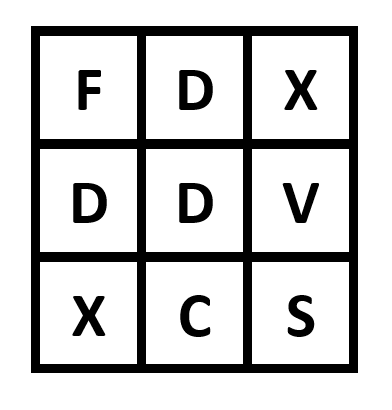

3 3
dimensione matrice 3x3

correzione immagine originale


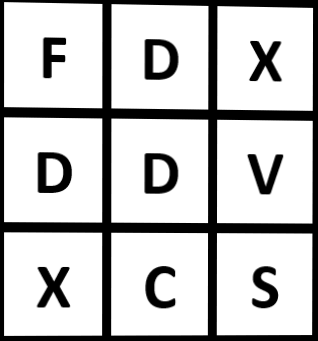

pulita


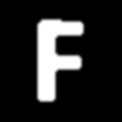

pulita


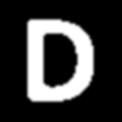

pulita


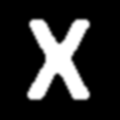

pulita


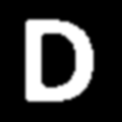

pulita


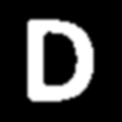

pulita


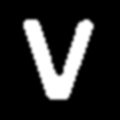

pulita


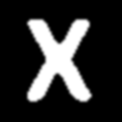

pulita


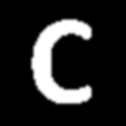

pulita


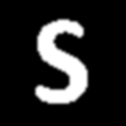

quadrati:  9


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_1 (Conv2D)           │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_layer_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_layer_2 (Conv2D)           │ (None, 9, 9, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_layer_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_layer (Dropout)            │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_layer (Flatten)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_1 (Dense)           │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_layer2 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer_2 (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,262 (391.65 KB)

...

 Non-trainable params: 0 (0.00 B)

Epoch 1/16


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(None, 784))
  warnings.warn(msg)


326/326 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - accuracy: 0.8344 - loss: 0.4480 - val_accuracy: 0.9856 - val_loss: 0.0498
Epoch 2/16
326/326 ━━━━━━━━━━━━━━━━━━━━ 38s 107ms/step - accuracy: 0.9864 - loss: 0.0479 - val_accuracy: 0.9920 - val_loss: 0.0297
Epoch 3/16
326/326 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.9893 - loss: 0.0399 - val_accuracy: 0.9933 - val_loss: 0.0259
Epoch 4/16
326/326 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.9918 - loss: 0.0300 - val_accuracy: 0.9945 - val_loss: 0.0252
Epoch 5/16
326/326 ━━━━━━━━━━━━━━━━━━━━ 41s 107ms/step - accuracy: 0.9941 - loss: 0.0213 - val_accuracy: 0.9940 - val_loss: 0.0237
Epoch 6/16
326/326 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.9939 - loss: 0.0197 - val_accuracy: 0.9941 - val_loss: 0.0229
Epoch 7/16
326/326 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - accuracy: 0.9944 - loss: 0.0169 - val_accuracy: 0.9950 - val_loss: 0.0214
Epoch 8/16
326/326 ━━━━━━━━━━━━━━━━━━━━ 36s 109ms/step - accuracy: 0.9962 - loss: 0.0167 - val

Test loss: 0.02269642986357212
Test accuracy: 0.9949048161506653


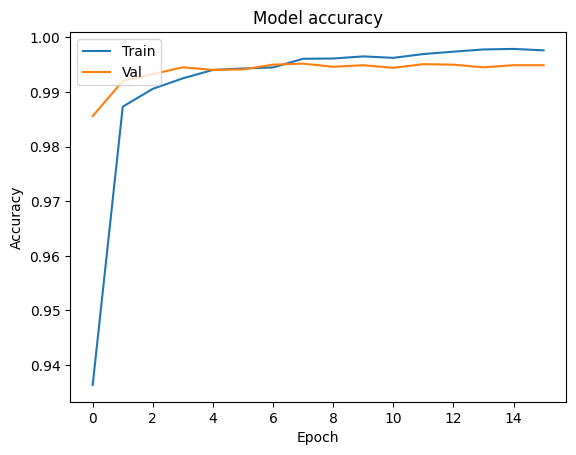

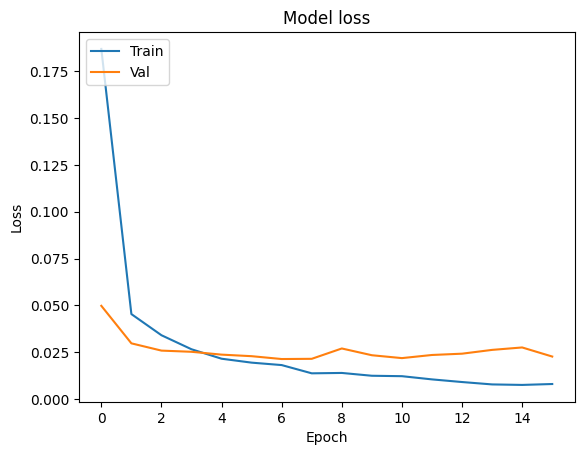

In [8]:
def trovaQuadrati(image, n, m, h, w):
  classes = np.zeros((n, m), dtype=np.uint8)
  cell_h = h/n
  cell_w = w/m
  quadrati = 0
  for i, j in product(range(n), range(m)):
      quadrati = quadrati+1
      cell_y = int(i*cell_h)
      cell_x = int(j*cell_w)
      cell = image[
              cell_y:cell_y+int(cell_h),
              cell_x:cell_x+int(cell_w)]

      cell = cv2.GaussianBlur(cell, (5, 5), 0)
      value, cell = cv2.threshold(cell, 0, 255, cv2.THRESH_BINARY|cv2.THRESH_OTSU)
      cell = 255-cell
      cell = cv2.morphologyEx(cell, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2)))

      letter = blob_cella(cell)
      figure = cv2.cvtColor(cell, cv2.COLOR_GRAY2BGR)
      figure[letter == 255] = (0, 0, 255)

      letter = ritaglia_contenuto(letter)
      letter = ritaglia_cella(letter, 1.5)
      letter = pulisci_cella(letter)
      cv2.imwrite(f'cella_{quadrati}.png', letter)
      print("pulita")
      cv2_imshow(letter)
  print("quadrati: ", quadrati)
  return quadrati

# Carica l'immagine da Google Drive
image = cv2.imread('/content/drive/MyDrive/prova12.png', cv2.IMREAD_GRAYSCALE)
image, n, m, h, w = trovaMatrice(image)
quadrati = trovaQuadrati(image, n, m, h, w)

#CARICAMENTO O CREAZIONE DEL MODELLO
from tensorflow.keras.models import load_model
if os.path.isfile('modello.h5'):
  model = load_model('modello.h5')
else:
  model, history = creaModello()

# Plot training & validation accuracy values
%matplotlib inline
plt.close('all')
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()



crazione della matrice  con le lettere previste

In [9]:
def crea_matrice_lettere(n, m, lettere_previste):
    # Crea una matrice vuota
    matrice_lettere = [['' for _ in range(m)] for _ in range(n)]

    # Riempie la matrice con le lettere previste
    for indice, lettera in enumerate(lettere_previste):
        row = indice // m
        col = indice % m
        matrice_lettere[row][col] = lettera

    return matrice_lettere

# Esempio di utilizzo
lettere_previste = previsioni(n, m, quadrati, model)
matrice_lettere = crea_matrice_lettere(n, m, lettere_previste)

# Stampa la matrice delle lettere previste
print("Matrice delle lettere previste:")
for row in matrice_lettere:
    print(row)




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 784))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Matrice delle lettere previste:
['f', 'd', 'x']
['d', 'd', 'v']
['x', 'c', 's']


In [10]:
# Determina le posizioni iniziale e finale del robot
pos_si, pos_sj = None, None
pos_fi, pos_fj = None, None

for i, row in enumerate(matrice_lettere):
    for j, cell in enumerate(row):
        if cell == 's':
            pos_si, pos_sj = i, j
        elif cell == 'f':
            pos_fi, pos_fj = i, j

if pos_si is None or pos_sj is None:
    raise ValueError("La posizione iniziale del robot non è stata trovata nella matrice delle lettere.")
if pos_fi is None or pos_fj is None:
    raise ValueError("La posizione finale del robot non è stata trovata nella matrice delle lettere.")

print(f"Posizione iniziale del robot: ({pos_si}, {pos_sj})")
print(f"Posizione finale del robot: ({pos_fi}, {pos_fj})")


Posizione iniziale del robot: (2, 2)
Posizione finale del robot: (0, 0)


In [11]:
import sys, os

py_file_location = "/content/aima"
sys.path.append(os.path.abspath(py_file_location))

print("Caricare la libreria aima.zip come distribuita nella pagina Unistudium del corso")
from google.colab import files
upload = files.upload()

Caricare la libreria aima.zip come distribuita nella pagina Unistudium del corso


Saving aima.zip to aima.zip


In [12]:
!unzip aima.zip

Archive:  aima.zip
   creating: aima/
  inflating: aima/search.py          
  inflating: aima/utils.py           
 extracting: aima/__init__.py        


In [13]:
%pip install numpy

In [14]:
from aima import Problem, Node, memoize, PriorityQueue
from aima import depth_first_graph_search, breadth_first_graph_search, iterative_deepening_search, depth_limited_search
from collections.abc import Callable
import time

In [15]:
class SmartVacuum(Problem):
    def __init__(self, initial, goal):
        self.initial = initial
        self.goal = goal

    def actions(self, state):
        robot_pos, grid = state
        x, y = robot_pos
        actions = []

        if x > 0 and grid[x-1][y] != 'X':
            actions.append('move up')
        if x < len(grid)-1 and grid[x+1][y] != 'X':
            actions.append('move down')
        if y > 0 and grid[x][y-1] != 'X':
            actions.append('move left')
        if y < len(grid[0])-1 and grid[x][y+1] != 'X':
            actions.append('move right')
        if grid[x][y] in ['D', 'V']:
            actions.append('clean')

        return actions

    def result(self, state, action):
        robot_pos, grid = state
        x, y = robot_pos
        new_grid = [row[:] for row in grid]

        if action == 'move up':
            new_robot_pos = (x-1, y)
        elif action == 'move down':
            new_robot_pos = (x+1, y)
        elif action == 'move left':
            new_robot_pos = (x, y-1)
        elif action == 'move right':
            new_robot_pos = (x, y+1)
        elif action == 'clean':
            new_robot_pos = (x, y)
            if new_grid[x][y] == 'D':
                new_grid[x][y] = 'C'
            elif new_grid[x][y] == 'V':
                new_grid[x][y] = 'D'

        return (new_robot_pos, new_grid)

    def goal_test(self, state):
        robot_pos, grid = state
        goal_pos, goal_grid = self.goal
        return robot_pos == goal_pos and all(cell not in ['D', 'V'] for row in grid for cell in row)

    def heuristic(self, state):
        robot_pos, grid = state
        goal_pos, goal_grid = self.goal
        x, y = robot_pos
        goal_x, goal_y = goal_pos
        return abs(x - goal_x) + abs(y - goal_y) + sum(cell in ['D', 'V'] for row in grid for cell in row)

In [17]:
import time
from typing import Callable

# Colori per output
RED = '\033[91m'
GREEN = '\033[92m'
RESET = '\033[0m'

In [18]:
def execute(name: str, algorithm: Callable, problem: Problem, *args, **kwargs) -> None:
    print(f"{RED}{name}{RESET}\n")
    start = time.time()
    sol = algorithm(problem, *args, **kwargs)
    end = time.time()

    if problem.goal is not None:
        print(f"\n{GREEN}PROBLEM:{RESET} {problem.initial} -> {problem.goal}")

    # Se l'oggetto della soluzione è un'istanza di Result vengono stampati i seguenti valori
    if isinstance(sol, Result):
        print(f"{GREEN}Total nodes generated:{RESET} {sol.nodes_generated}")
        print(f"{GREEN}Paths explored:{RESET} {sol.paths_explored}")
        print(f"{GREEN}Nodes left in frontier:{RESET} {sol.nodes_left_in_frontier}")
        sol = sol.result  # estrazione Node

    # Se non viene trovata soluzione
    print(f"{GREEN}Result:{RESET} {sol.solution() if sol is not None else '---'}")

    # Se la soluzione è un nodo finale stampa anche i seguenti valori
    if isinstance(sol, Node):
        print(f"{GREEN}Path Cost:{RESET} {sol.path_cost}")
        print(f"{GREEN}Path Length:{RESET} {sol.depth}")

        # Stampa la griglia con il percorso
        print(f"\n{GREEN}Path Visualization:{RESET}\n")
        percorso(problem, sol)

    print(f"{GREEN}Time:{RESET} {end - start} s")

def percorso(problem: Problem, node: Node) -> None:
    path = node.path()  # Ottieni il percorso dal nodo iniziale a quello finale

    # Stampa di ogni step del percorso
    for idx, step in enumerate(path):
        print(f"Step {idx}:")
        robot_pos, grid = step.state
        action = step.action if step.action else "Initial State"
        print(f"Action: {action}")
        print(f"Robot position: {robot_pos}")
        stampa_griglia(grid, robot_pos, problem.goal)
        print("\n")

def stampa_griglia(grid, robot_pos, goal_state):
    """Stampa la griglia con la posizione del robot"""
    goal_pos, goal_grid = goal_state
    n = len(grid)
    m = len(grid[0])

    for i in range(n):
        for j in range(m):
            if (i, j) == robot_pos:
                # Mostra il robot con 'R' ma mantieni la cella finale se è 'f'
                if grid[i][j] == 'f':
                    print("R", end=" ")
                else:
                    print("R", end=" ")
            else:
                print(grid[i][j], end=" ")
        print()  # Va a capo alla fine di ogni riga


In [28]:
class Result:
    """Classe per contenere i risultati degli algoritmi di ricerca"""

    def __init__(self, result, nodes_generated, paths_explored, nodes_left_in_frontier):
        self.result = result
        self.nodes_generated = nodes_generated
        self.paths_explored = paths_explored
        self.nodes_left_in_frontier = nodes_left_in_frontier

def result(node, nodes_generated, paths_explored, nodes_left_in_frontier):
    """Crea un oggetto Result per compatibilità con la funzione execute"""
    return Result(
        result=node,
        nodes_generated=nodes_generated,
        paths_explored=paths_explored,
        nodes_left_in_frontier=nodes_left_in_frontier
    )

ce qu'il me manque , la creation des algos et leurs executions , e de tout tester

In [26]:
from collections import deque

def state_to_hashable(state):
    """Converte lo stato in una forma hashable per i set"""
    robot_pos, grid = state
    return (robot_pos, tuple(tuple(row) for row in grid))

def breadth_first_graph_search(problem: Problem) -> result:
    """
    Implementazione BFS per il problema SmartVacuum
    Ritorna un oggetto Result compatibile con la funzione execute
    """
    node = Node(problem.initial)
    frontier = deque([node])  # Coda FIFO per BFS
    frontier_set = {state_to_hashable(node.state)}  # Set per controllo O(1) se stato è in frontier
    explored = set()
    counter = 1  # Nodi generati

    while frontier:
        node = frontier.popleft()  # Estrai il primo nodo (FIFO)
        frontier_set.remove(state_to_hashable(node.state))  # Rimuovi dal set di controllo

        if problem.goal_test(node.state):
            return result(node, counter, len(explored), len(frontier))

        explored.add(state_to_hashable(node.state))

        # Espansione figli
        for child in node.expand(problem):
            counter += 1
            hashable_state = state_to_hashable(child.state)
            if hashable_state not in explored and hashable_state not in frontier_set:
                frontier.append(child)
                frontier_set.add(hashable_state)

    return result(None, counter, len(explored), 0)  # Nessuna soluzione trovata

In [29]:
# Esecuzione BFS per SmartVacuum

# 1. Convertire lettere in maiuscole per compatibilità con SmartVacuum
matrice_lettere_upper = [[cell.upper() for cell in row] for row in matrice_lettere]

# 2. Creare lo stato iniziale e finale
initial_state = ((pos_si, pos_sj), matrice_lettere_upper)
goal_state = ((pos_fi, pos_fj), matrice_lettere_upper)

# 3. Creare il problema SmartVacuum
problem = SmartVacuum(initial_state, goal_state)

print("=" * 50)
print("SMART VACUUM - BFS EXECUTION")
print("=" * 50)

# 4. Stampa informazioni iniziali
print(f"Dimensioni griglia: {len(matrice_lettere_upper)} x {len(matrice_lettere_upper[0])}")
print(f"Posizione iniziale: ({pos_si}, {pos_sj})")
print(f"Posizione finale: ({pos_fi}, {pos_fj})")

# Conta le celle da pulire
dirty_count = sum(1 for row in matrice_lettere_upper for cell in row if cell in ['D', 'V'])
print(f"Celle da pulire: {dirty_count}")

print("\nGriglia iniziale:")
stampa_griglia(matrice_lettere_upper, (pos_si, pos_sj), goal_state)

print("\n" + "=" * 50)

# 5. Eseguire BFS
execute("BFS Search", breadth_first_graph_search, problem)

print("=" * 50)

SMART VACUUM - BFS EXECUTION
Dimensioni griglia: 3 x 3
Posizione iniziale: (2, 2)
Posizione finale: (0, 0)
Celle da pulire: 4

Griglia iniziale:
F D X 
D D V 
X C R 

BFS Search


PROBLEM: ((2, 2), [['F', 'D', 'X'], ['D', 'D', 'V'], ['X', 'C', 'S']]) -> ((0, 0), [['F', 'D', 'X'], ['D', 'D', 'V'], ['X', 'C', 'S']])
Total nodes generated: 425
Paths explored: 162
Nodes left in frontier: 4
Result: ['move up', 'clean', 'clean', 'move left', 'move up', 'clean', 'move down', 'clean', 'move left', 'clean', 'move up']
Path Cost: 11
Path Length: 11

Path Visualization:

Step 0:
Action: Initial State
Robot position: (2, 2)
F D X 
D D V 
X C R 


Step 1:
Action: move up
Robot position: (1, 2)
F D X 
D D R 
X C S 


Step 2:
Action: clean
Robot position: (1, 2)
F D X 
D D R 
X C S 


Step 3:
Action: clean
Robot position: (1, 2)
F D X 
D D R 
X C S 


Step 4:
Action: move left
Robot position: (1, 1)
F D X 
D R C 
X C S 


Step 5:
Action: move up
Robot position: (0, 1)
F R X 
D D C 
X C S 


Step 6:
A

In [30]:
# creazione di algorithmi de A*
import heapq

def state_to_hashable(state):
    """Converte lo stato in una forma hashable per i set"""
    robot_pos, grid = state
    return (robot_pos, tuple(tuple(row) for row in grid))

def astar_search(problem: Problem) -> Result:
    """
    Implementazione A* per il problema SmartVacuum
    Usa f(n) = g(n) + h(n) dove:
    - g(n) = costo del percorso dal nodo iniziale
    - h(n) = euristica (distanza Manhattan + celle da pulire)
    """
    node = Node(problem.initial)
    frontier = []  # Coda di priorità per A*
    heapq.heappush(frontier, (node.path_cost + problem.heuristic(node.state), node))
    frontier_dict = {state_to_hashable(node.state): node.path_cost + problem.heuristic(node.state)}
    explored = set()
    counter = 1  # Nodi generati

    while frontier:
        f_cost, node = heapq.heappop(frontier)  # Estrai il nodo con f(n) minimo
        hashable_state = state_to_hashable(node.state)

        # Rimuovi dal dizionario di controllo
        if hashable_state in frontier_dict:
            del frontier_dict[hashable_state]

        if problem.goal_test(node.state):
            return result(node, counter, len(explored), len(frontier))

        explored.add(hashable_state)

        # Espansione figli
        for child in node.expand(problem):
            counter += 1
            hashable_child_state = state_to_hashable(child.state)
            child_f_cost = child.path_cost + problem.heuristic(child.state)

            if hashable_child_state not in explored:
                # Se non è nella frontier o ha un costo migliore
                if (hashable_child_state not in frontier_dict or
                    child_f_cost < frontier_dict[hashable_child_state]):

                    heapq.heappush(frontier, (child_f_cost, child))
                    frontier_dict[hashable_child_state] = child_f_cost

    return result(None, counter, len(explored), 0)  # Nessuna soluzione trovata


In [31]:
# Esecuzione A* per SmartVacuum

print("\n" + "=" * 50)
print("SMART VACUUM - A* EXECUTION")
print("=" * 50)

# Usa gli stessi stati iniziale e finale della BFS
print(f"Dimensioni griglia: {len(matrice_lettere_upper)} x {len(matrice_lettere_upper[0])}")
print(f"Posizione iniziale: ({pos_si}, {pos_sj})")
print(f"Posizione finale: ({pos_fi}, {pos_fj})")

# Conta le celle da pulire
dirty_count = sum(1 for row in matrice_lettere_upper for cell in row if cell in ['D', 'V'])
print(f"Celle da pulire: {dirty_count}")

print("\nGriglia iniziale:")
stampa_griglia(matrice_lettere_upper, (pos_si, pos_sj), goal_state)

print("\n" + "=" * 50)

# Eseguire A*
execute("A* Search", astar_search, problem)

print("=" * 50)


SMART VACUUM - A* EXECUTION
Dimensioni griglia: 3 x 3
Posizione iniziale: (2, 2)
Posizione finale: (0, 0)
Celle da pulire: 4

Griglia iniziale:
F D X 
D D V 
X C R 

A* Search


PROBLEM: ((2, 2), [['F', 'D', 'X'], ['D', 'D', 'V'], ['X', 'C', 'S']]) -> ((0, 0), [['F', 'D', 'X'], ['D', 'D', 'V'], ['X', 'C', 'S']])
Total nodes generated: 188
Paths explored: 71
Nodes left in frontier: 37
Result: ['move up', 'clean', 'clean', 'move left', 'clean', 'move left', 'clean', 'move up', 'move right', 'clean', 'move left']
Path Cost: 11
Path Length: 11

Path Visualization:

Step 0:
Action: Initial State
Robot position: (2, 2)
F D X 
D D V 
X C R 


Step 1:
Action: move up
Robot position: (1, 2)
F D X 
D D R 
X C S 


Step 2:
Action: clean
Robot position: (1, 2)
F D X 
D D R 
X C S 


Step 3:
Action: clean
Robot position: (1, 2)
F D X 
D D R 
X C S 


Step 4:
Action: move left
Robot position: (1, 1)
F D X 
D R C 
X C S 


Step 5:
Action: clean
Robot position: (1, 1)
F D X 
D R C 
X C S 


Step 6:
A

In [32]:
# Confronto completo BFS vs A* per SmartVacuum

# 1. Convertire lettere in maiuscole per compatibilità con SmartVacuum
matrice_lettere_upper = [[cell.upper() for cell in row] for row in matrice_lettere]

# 2. Creare lo stato iniziale e finale
initial_state = ((pos_si, pos_sj), matrice_lettere_upper)
goal_state = ((pos_fi, pos_fj), matrice_lettere_upper)

# 3. Creare il problema SmartVacuum
problem = SmartVacuum(initial_state, goal_state)

print("=" * 60)
print("SMART VACUUM - BFS vs A* COMPARISON")
print("=" * 60)

# 4. Stampa informazioni iniziali
print(f"Dimensioni griglia: {len(matrice_lettere_upper)} x {len(matrice_lettere_upper[0])}")
print(f"Posizione iniziale: ({pos_si}, {pos_sj})")
print(f"Posizione finale: ({pos_fi}, {pos_fj})")

# Conta le celle da pulire
dirty_count = sum(1 for row in matrice_lettere_upper for cell in row if cell in ['D', 'V'])
print(f"Celle da pulire: {dirty_count}")

print("\nGriglia iniziale:")
stampa_griglia(matrice_lettere_upper, (pos_si, pos_sj), goal_state)

print("\n" + "=" * 60)

# 5. Eseguire BFS
execute("BFS Search", breadth_first_graph_search, problem)

print("\n" + "=" * 60)

# 6. Eseguire A*
execute("A* Search", astar_search, problem)

print("=" * 60)

SMART VACUUM - BFS vs A* COMPARISON
Dimensioni griglia: 3 x 3
Posizione iniziale: (2, 2)
Posizione finale: (0, 0)
Celle da pulire: 4

Griglia iniziale:
F D X 
D D V 
X C R 

BFS Search


PROBLEM: ((2, 2), [['F', 'D', 'X'], ['D', 'D', 'V'], ['X', 'C', 'S']]) -> ((0, 0), [['F', 'D', 'X'], ['D', 'D', 'V'], ['X', 'C', 'S']])
Total nodes generated: 425
Paths explored: 162
Nodes left in frontier: 4
Result: ['move up', 'clean', 'clean', 'move left', 'move up', 'clean', 'move down', 'clean', 'move left', 'clean', 'move up']
Path Cost: 11
Path Length: 11

Path Visualization:

Step 0:
Action: Initial State
Robot position: (2, 2)
F D X 
D D V 
X C R 


Step 1:
Action: move up
Robot position: (1, 2)
F D X 
D D R 
X C S 


Step 2:
Action: clean
Robot position: (1, 2)
F D X 
D D R 
X C S 


Step 3:
Action: clean
Robot position: (1, 2)
F D X 
D D R 
X C S 


Step 4:
Action: move left
Robot position: (1, 1)
F D X 
D R C 
X C S 


Step 5:
Action: move up
Robot position: (0, 1)
F R X 
D D C 
X C S 


St